In [1]:
import os
from dotenv import load_dotenv 
load_dotenv(override=True)

True

In [2]:
from langchain_deepseek import ChatDeepSeek

model = ChatDeepSeek(model="deepseek-chat")

In [3]:
question = "你好，请你介绍一下你自己。"

result = model.invoke(question)
print(result.content)

你好！很高兴认识你！😊

我是DeepSeek，由深度求索公司创造的AI助手。让我来详细介绍一下自己：

**我的特点：**
- 💬 纯文本对话模型，擅长理解和生成自然语言
- 📁 支持文件上传功能——可以处理图像、txt、pdf、ppt、word、excel等文件，并从中读取文字信息
- 🌐 具备联网搜索能力（需要你在Web/App中手动开启）
- 💾 拥有128K的上下文长度，能记住我们对话中的很多细节

**我能帮你做什么：**
- 回答各种问题，从日常生活到专业领域
- 协助写作、翻译、分析和总结
- 帮你理解和处理上传的文档内容
- 进行创意思考和问题解决
- 学习辅导和知识解释

**重要说明：**
- 我完全免费使用，没有任何收费计划
- 你可以通过官方应用商店下载App
- 我的知识截止到2024年7月，是DeepSeek的最新版本

我的回复风格比较热情细腻，希望能给你带来愉快的交流体验！有什么想聊的或需要帮助的，尽管告诉我吧！✨


### 1. 文档加载（Document Loaders）

&emsp;&emsp;这意味着，我们可以通过调用`LangChain`抽象好的方法直接处理私有数据，无需手动编写中间的处理流程，并且每一种文档的加载器，在`LangChain`官方文档中都有基本的调用示例供我们快速上手使用，具体位置如下：https://python.langchain.com/docs/integrations/document_loaders/

&emsp;&emsp;各个不同类型的文档加载器经过`langChain`的高度封装后使用起来并不会很复杂，可以直接调用`load_documents`方法，传入文件路径，就可以加载出对应的文档。这里我们进行几种不同类型的文档加载，并查看加载后的文档内容。

### 2. RAG系统的文档切分策略

#### 2.1 通用文档切分策略

In [4]:
import re

def split_text_by_punctuation(text):
    # 定义一个正则表达式，包括常见的中英文标点
    # pattern = r"[。！？｡＂＃＄％＆＇（）＊＋，－／：；＜＝＞＠［＼］＾＿｀｛｜｝～\s、]+"
    pattern = r"[。！？｡]+"
    # 使用正则表达式进行分割
    segments = re.split(pattern, text)
    # 过滤掉空字符串
    return [segment for segment in segments if segment]

&emsp;&emsp;这个函数会根据中文和英文的标点符号来分割文本，并移除空字符串。定义好分割函数后，我们可以尝试进行功能测试：

In [5]:
# 文本
text = "春节的脚步越来越近，大街小巷都布满了节日的气氛。商店门口挂满了红灯笼和春联，家家户户都在忙着打扫卫生，准备迎接新的一年。\
小明回到家乡，感受到了浓浓的过年氛围。他在街上走着，看到小朋友们手持烟花棒，欢笑声此起彼伏。\
夜幕降临，整个城市亮起了五彩缤纷的灯光，映照着人们脸上的喜悦与期待。老人们聚在一起，回忆过去，展望未来。\
而年轻人则在夜市享受美食，放松心情。这是一个充满希望和喜悦的时刻，每个人都在以自己的方式庆祝这个特殊的节日。"

# 调用函数进行分割
segments = split_text_by_punctuation(text)

# 使用循环来打印每个chunk
for i, segment in enumerate(segments):
    print("Chunk {}: {}".format(i + 1, segment))

Chunk 1: 春节的脚步越来越近，大街小巷都布满了节日的气氛
Chunk 2: 商店门口挂满了红灯笼和春联，家家户户都在忙着打扫卫生，准备迎接新的一年
Chunk 3: 小明回到家乡，感受到了浓浓的过年氛围
Chunk 4: 他在街上走着，看到小朋友们手持烟花棒，欢笑声此起彼伏
Chunk 5: 夜幕降临，整个城市亮起了五彩缤纷的灯光，映照着人们脸上的喜悦与期待
Chunk 6: 老人们聚在一起，回忆过去，展望未来
Chunk 7: 而年轻人则在夜市享受美食，放松心情
Chunk 8: 这是一个充满希望和喜悦的时刻，每个人都在以自己的方式庆祝这个特殊的节日


&emsp;&emsp;如上所示，一整段`text`会根据设定的标点符号被分割为多个`chunks`，当然如果有特定的分割需求（比如保留某些特定的标点符号），可以调整正则表达式来灵活的调整。

- **按照固定字符数切分**

&emsp;&emsp;如果想按照固定字符数来切分文本，这种方法就不再依赖于标点符号，而是简单地按照给定的字符数来切分文本。我们可以编写一个函数，用来将文本分割成指定长度的片段。代码如下：

In [6]:
def split_text_by_fixed_length(text, length):
    # 使用列表推导式按固定长度切分文本
    return [text[i:i + length] for i in range(0, len(text), length)]

&emsp;&emsp;这个函数的作用是根据指定的长度（在这个例子中为100个字符）来切分文本。我们可以根据具体需要调整这个长度。

In [7]:
# 文本
text = "春节的脚步越来越近，大街小巷都布满了节日的气氛。商店门口挂满了红灯笼和春联，家家户户都在忙着打扫卫生，准备迎接新的一年。\
小明回到家乡，感受到了浓浓的过年氛围。他在街上走着，看到小朋友们手持烟花棒，欢笑声此起彼伏。\
夜幕降临，整个城市亮起了五彩缤纷的灯光，映照着人们脸上的喜悦与期待。老人们聚在一起，回忆过去，展望未来。\
而年轻人则在夜市享受美食，放松心情。这是一个充满希望和喜悦的时刻，每个人都在以自己的方式庆祝这个特殊的节日。"

# 定义每个片段的长度
chunk_length = 100

# 调用函数进行分割
result = split_text_by_fixed_length(text, chunk_length)

# 打印结果
for i, segment in enumerate(result):
    print(f"Chunk {i+1}: {segment}")

Chunk 1: 春节的脚步越来越近，大街小巷都布满了节日的气氛。商店门口挂满了红灯笼和春联，家家户户都在忙着打扫卫生，准备迎接新的一年。小明回到家乡，感受到了浓浓的过年氛围。他在街上走着，看到小朋友们手持烟花棒，欢笑
Chunk 2: 声此起彼伏。夜幕降临，整个城市亮起了五彩缤纷的灯光，映照着人们脸上的喜悦与期待。老人们聚在一起，回忆过去，展望未来。而年轻人则在夜市享受美食，放松心情。这是一个充满希望和喜悦的时刻，每个人都在以自己的
Chunk 3: 方式庆祝这个特殊的节日。


&emsp;&emsp;然而，这种方法的一个明显缺点是由于仅依据长度进行切分，切分后的片段可能无法保持完整的语义。但并不意味着它不适用于文本切分任务。例如，这种方法非常适合于处理日志文件或代码块，其中文本通常以固定长度或格式出现，或者在处理来自传感器或其他实时数据源的流数据时，固定长度切分可以确保数据被均匀地处理和分析。这些应用场景中，数据的结构和形式通常是预定和规范的，因此即便是按固定长度进行切分，反而会更有利于对数据的理解和使用。

- **结合重叠窗口的固定字符数切分**

&emsp;&emsp;重复窗口的意义是：块之间保持一些重叠，以确保语义上下文不会在块之间丢失。在文本处理和其他数据分析领域，"重叠"（overlap）指的是连续数据块之间共享的部分。这种方法特别常见于信号处理、语音分析、自然语言处理等领域，其中数据的连续性和上下文信息非常重要。比如下述代码所示：

In [8]:
def split_text_by_fixed_length_with_overlap(text, length, overlap):
    # 使用列表推导式按固定长度及重叠长度切分文本
    return [text[i:i + length] for i in range(0, len(text) - overlap, length - overlap)]

&emsp;&emsp;调用测试：

In [9]:
# 文本
text = "春节的脚步越来越近，大街小巷都布满了节日的气氛。商店门口挂满了红灯笼和春联，家家户户都在忙着打扫卫生，准备迎接新的一年。\
小明回到家乡，感受到了浓浓的过年氛围。他在街上走着，看到小朋友们手持烟花棒，欢笑声此起彼伏。\
夜幕降临，整个城市亮起了五彩缤纷的灯光，映照着人们脸上的喜悦与期待。老人们聚在一起，回忆过去，展望未来。\
而年轻人则在夜市享受美食，放松心情。这是一个充满希望和喜悦的时刻，每个人都在以自己的方式庆祝这个特殊的节日。"

# 定义每个片段的长度和重叠长度
chunk_length = 100
overlap_length = 30

# 调用函数进行分割
result = split_text_by_fixed_length_with_overlap(text, chunk_length, overlap_length)

# 打印结果
for i, segment in enumerate(result):
    print(f"Chunk {i+1}: {segment}")

Chunk 1: 春节的脚步越来越近，大街小巷都布满了节日的气氛。商店门口挂满了红灯笼和春联，家家户户都在忙着打扫卫生，准备迎接新的一年。小明回到家乡，感受到了浓浓的过年氛围。他在街上走着，看到小朋友们手持烟花棒，欢笑
Chunk 2: 了浓浓的过年氛围。他在街上走着，看到小朋友们手持烟花棒，欢笑声此起彼伏。夜幕降临，整个城市亮起了五彩缤纷的灯光，映照着人们脸上的喜悦与期待。老人们聚在一起，回忆过去，展望未来。而年轻人则在夜市享受美食
Chunk 3: 老人们聚在一起，回忆过去，展望未来。而年轻人则在夜市享受美食，放松心情。这是一个充满希望和喜悦的时刻，每个人都在以自己的方式庆祝这个特殊的节日。


&emsp;&emsp;如上所示，每个文本片段长度为100个字符，并且每个片段与下一个片段有30个字符的重叠。这样，每个窗口实际上是在上一个窗口向前移动30个字符的基础上开始的。这种方法特别适用于需要数据重叠以保持上下文连续性的情况，能够较好的在某一个chunk中保存某个完整的语义信息，比如在第一个Chunk中的：'他在街上走着，看到小朋友们手持烟花棒，欢笑'被截断，但是完整的语义能够在Chunk2中被存储：'他在街上走着，看到小朋友们手持烟花棒，欢笑声此起彼伏。' 那么当这条语义信息是有关于Query的上下文，就可以在chunk2中被检索出来。

&emsp;&emsp;在大多数情况下，结合overlap windows的固定大小的分块是一种更加经济且易于使用的方式。因为它在分块过程中不需要使用任何NLP库或者模型等。

&emsp;&emsp;如上所示的前三种方法涉及的是对数据静态字符的切分，这些方法基本上只会将文本分割成固定数量字符的片段，而不考虑其内容或结构。这些是最基本且相对简单实现的文本切分方式。相比之下，递归方法的切分策略更为通用且常用，但实现上稍显复杂。为了简化实现过程，我们可以直接利用LangChain提供的封装类来进行实践。此外，LangChain也提供了相应的实现类来支持按照句子切分、固定字符数切分以及结合重叠窗口（overlap windows）的固定字符切分方法，我们将会逐一探索这些方法的应用。

#### 2.2 LangChain中的Text Splitters工具调用方法

&emsp;&emsp;LangChain框架构造了`Data connection`这一原生的数据处理流来统一管理RAG的处理流程。在这个架构中，文档切分的过程对应于`Transformer`环节，这一部分的任务是将整个`Document`对象转化（或“转换”）成多个小块（chunks）。这一转化步骤确立了文档从完整对象到细分片段的具体切分逻辑。

<div align=center><img src="https://snowball101.oss-cn-beijing.aliyuncs.com/img/202404161408686.png" width=80%></div>

在实际应用中，开发者可以灵活组合这些分块器，针对不同的内容类型采取最优的策略。例如，针对技术文档，可以先用**Markdown Header Splitter**保留章节层次，再使用**Recursive Character Splitter**对较长片段进行二次切分；而在代码检索场景，**Code Splitter**可以根据函数或类边界划分逻辑单元，从而提高查询的精准性和可读性。

- **CharacterTextSplitter**

&emsp;&emsp;这是最简单的方法。其基于字符（默认为“”）进行分割，并通过字符数来测量块长度。要使用该方法，需要先进行导入：

In [10]:
from langchain_text_splitters import CharacterTextSplitter

&emsp;&emsp;这里先导入一个测试文本：

In [11]:
# This is a long document we can split up.
with open("sora.txt", encoding="utf-8") as f:
    langchain_desc = f.read()

In [12]:
langchain_desc

'一、Sora是什么？为什么说Sora是人工智能划时代的突破?\\n\\n2024年2月16日凌晨，OpenAI在官网发布了最新的文生视频模型Sora。Sora不仅突破了现有文生视频模型10秒左右的连贯性局限，而且展示出了更精细的画质、多角度多镜头切换中保持一致性等能力。最重要的是，Sora较好地表现出了现实世界中的逻辑，比如在模型生成的两艘海盗船在咖啡杯内航行的视频中，咖啡的流动完全符合现实世界中的流体力学；比如一则宠物猫等待主人起床的视频中，宠物猫踩奶的动作、对主人鼻头的轻触都符合现实世界中动物的习性。\\n\\n尽管出于安全性和测试验证等原因，Sora尚未开放给公众使用，但通过观察OpenAI发布的demo，不难发现Sora已经初步具备了理解现实世界运行规律的能力，即“涌现”的能力被成功得从大语言模型复制到了文生视频模型中。假以时日，人类或将很难区分现实世界和由AI生成的虚拟世界。除了为视频制作、电影剪辑、游戏设计等工作提升效率外，一个完全由数据驱动的数字世界或许已经近在咫尺。英伟达人工智能研究院首席科学家JimFan称“这是视频生成领域的GPT-3时刻”。360董事长周鸿祎称“Sora意味着AGI（通用人工智能）实现将从10年缩短到1年”。\\n\\n二、Sora是如何实现的？\\n\\n尽管OpenAI在Sora的技术文档中并未公开所有模型细节，但我们可以通过其描述大致推测出，Sora的实现仍然依赖于OpenAI在大语言模型领域取得巨大成功的“大力出奇迹”思想，即通过大幅提升训练数据和参数规模实现视频精度和对现实世界物理关系的“涌现”。\\n\\n相比GPT模型，Sora的成功之处在于为图像视频等多模态数据找到了适合Transformer架构的表征方式，从而将ScalingLaw从语言模型复制到了图像视频模型。此外，Sora在训练时还借助了DALL·E3生成的高质量文本描述，在推理时借助了GPT对用户输入进行扩展，可谓“站在巨人肩膀上”更进一步。\\n\\n三、Sora对AI应用和算力需求带来哪些影响?\\n\\n对于应用而言，Sora生成的视频已经达到了大部分消费级场景的使用要求，将为短视频创作等创意产业带来繁荣。随着模型升级，预计也将对电影、游戏等行业的制作效率带来大幅提升。尽管Sora的商业化时间表还未披露，但ChatGPT之后又一风靡全球的AI杀手

&emsp;&emsp;这里可以看到，其初始化方法中需要传递一个`separator`，默认是以`"\n\n"`进行分割。虽然它并没有定义额外的初始化参数，但因为其继承了`TextSplitter`，所以在`TextSplitter`类中定义的参数，在`CharacterTextSplitter`类中都可以直接使用。所以我们可以实例化出这样一个`CharacterTextSplitter`。

In [13]:
text_splitter = CharacterTextSplitter(separator='\\n',
                                     chunk_size = 350, 
                                      chunk_overlap=40,)

&emsp;&emsp;先看其`split_text(text)`方法，它需要传入的是字符串形式的一段文本，功能是`separator`参数设定的分隔符进行文本分割。所以这里我们可以直接传入一个字符串类型的文本。

In [14]:
type(langchain_desc)

str

In [15]:
text_res = text_splitter.split_text(langchain_desc)

In [16]:
len(text_res)

8

In [17]:
text_res[0]

'一、Sora是什么？为什么说Sora是人工智能划时代的突破?\\n2024年2月16日凌晨，OpenAI在官网发布了最新的文生视频模型Sora。Sora不仅突破了现有文生视频模型10秒左右的连贯性局限，而且展示出了更精细的画质、多角度多镜头切换中保持一致性等能力。最重要的是，Sora较好地表现出了现实世界中的逻辑，比如在模型生成的两艘海盗船在咖啡杯内航行的视频中，咖啡的流动完全符合现实世界中的流体力学；比如一则宠物猫等待主人起床的视频中，宠物猫踩奶的动作、对主人鼻头的轻触都符合现实世界中动物的习性。'

In [18]:
text_res[1]

'尽管出于安全性和测试验证等原因，Sora尚未开放给公众使用，但通过观察OpenAI发布的demo，不难发现Sora已经初步具备了理解现实世界运行规律的能力，即“涌现”的能力被成功得从大语言模型复制到了文生视频模型中。假以时日，人类或将很难区分现实世界和由AI生成的虚拟世界。除了为视频制作、电影剪辑、游戏设计等工作提升效率外，一个完全由数据驱动的数字世界或许已经近在咫尺。英伟达人工智能研究院首席科学家JimFan称“这是视频生成领域的GPT-3时刻”。360董事长周鸿祎称“Sora意味着AGI（通用人工智能）实现将从10年缩短到1年”。\\n二、Sora是如何实现的？'

- **RecursiveCharacterTextSplitter**

&emsp;&emsp;在上一小节的三种切分方法下，虽然简单且更容易理解，但其存在的核心问题是：完全忽视了文档的结构，只是单纯按固定字符数量进行切分。所以难免要更进一步地去做优化，那么一个更进阶的文本分割器应该具备的是：

- 能够将文本分成小的、具有语义意义的块（通常是句子）。
- 可以通过某些测量方法，将这些小块组合成一个更大的块，直到达到一定的大小。
- 一旦达到该大小，请将该块设为自己的文本片段，然后创建具有一些重叠的新文本块，以保持块之间的上下文。

&emsp;&emsp;根据上述需求，衍生出来的就是递归字符文本切分器，在`langChain`中的抽象类为：`RecursiveCharacterTextSplitter`，同时它也是`Langchain`的默认文本分割器，在`Baseloader`类中，

&emsp;&emsp;首先，还是需要进行模块的导入：

In [19]:
# ! pip install --upgrade --quiet langchain-text-splitters tiktoken

In [20]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [21]:
with open("./sora.txt", encoding="utf-8") as f:
    langchain_desc = f.read()

In [22]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [23]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    model_name="gpt-4o",
    chunk_size=100, #块长度
    chunk_overlap=0, #重叠字符串长度

)

In [24]:
texts = text_splitter.split_text(langchain_desc)
print(texts[0])

一、Sora是什么？为什么说Sora是人工智能划时代的突破?\n\n2024年2月16日凌晨，OpenAI在官网发布了最新的文生视频模型Sora。Sora不仅突破了现有文生视频模型10秒左右的连贯性局


In [25]:
len(texts)

22

#### 2.4 处理特定数据文档切分

&emsp;&emsp;在上面的介绍中，无论是手动实现还是借助于`LangChain`抽象好的文档加载器，均更倾向于处理普通的文本文件（如 .txt）。而当遇到更复杂的数据格式，如`JSON`、`PDF`等，之前的处理方式就并不再适用，此时考虑的应该是如何将文本分割的策略正确地匹配到具体的数据格式。 

&emsp;&emsp;比如对于Markdown来说，其文档分割器为`MarkdownTextSplitter`。先导入

In [26]:
from langchain_text_splitters import MarkdownTextSplitter

&emsp;&emsp;定义一个测试文本：

In [27]:
markdown_text = """
# 主题：技术探讨

## 第一部分：前言

这是前言部分，简短介绍文档主旨。

## 第二部分：技术分析

### Python编程

### 解释

1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。
2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。
3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。
"""

&emsp;&emsp;构造文档切割器的实例：

In [28]:
splitter = MarkdownTextSplitter(chunk_size = 60, chunk_overlap=10)

&emsp;&emsp;按照`MarkdownTextSplitter`定义的分隔符进行切分，调用`create_documents`方法。

In [29]:
mardown_split = splitter.create_documents([markdown_text])

In [30]:
len(mardown_split)

5

In [31]:
mardown_split

[Document(metadata={}, page_content='# 主题：技术探讨\n\n## 第一部分：前言\n\n这是前言部分，简短介绍文档主旨。\n\n## 第二部分：技术分析'),
 Document(metadata={}, page_content='### Python编程\n\n### 解释'),
 Document(metadata={}, page_content='1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。'),
 Document(metadata={}, page_content='2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。'),
 Document(metadata={}, page_content='3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。')]

&emsp;&emsp;同时，LangChain封装的`MarkdownHeaderTextSplitter`，它的切分逻辑是基于指定的标题来分割`markdown`文件。因为`Markdown`格式有特定的语法，一般整体内容由`h1、h2、h3`等多级标题组织，所以`MarkdownHeaderTextSplitter`得切分策略就是根据标题来分割文本内容。

In [32]:
# ! pip install -qU langchain-text-splitters

In [33]:
markdown_text = """
# 主题：技术探讨

## 第一部分：前言

这是前言部分，简短介绍文档主旨。

## 第二部分：技术分析

### Python编程

### 解释
 
1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。
2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。
3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。
"""

In [34]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
md_header_splits = markdown_splitter.split_text(markdown_text)

In [35]:
print(md_header_splits)

[Document(metadata={'Header 1': '主题：技术探讨', 'Header 2': '第一部分：前言'}, page_content='这是前言部分，简短介绍文档主旨。'), Document(metadata={'Header 1': '主题：技术探讨', 'Header 2': '第二部分：技术分析', 'Header 3': '解释'}, page_content='1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。\n2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。\n3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。')]


&emsp;&emsp;从输出上看，切分策略会根据指定标题(标题1, 标题2,标题3) ，且同一标题内的的数据被放置在同一个块内。

&emsp;&emsp;除此之外，还有一个`CodeTextSplitter`,可以按照代码进行分割，支持代码的语言包括['cpp', 'go', 'java', 'js', 'php', 'proto', 'python', 'rst', 'ruby', 'rust', 'scala', 'swift', 'markdown', 'latex', 'html', 'sol']，比如Markdown(来源于`RecursiveCharacterTextSplitter`的`get_separators_for_language`方法)：
```python
        elif language == Language.MARKDOWN:
            return [
                # First, try to split along Markdown headings (starting with level 2)
                "\n#{1,6} ",   #  根据标题（H1 到 H6）来分割
                # Note the alternative syntax for headings (below) is not handled here
                # Heading level 2
                # ---------------
                # End of code block
                "```\n",      # 代码块
                # Horizontal lines   
                "\n\\*\\*\\*+\n",   # 水平线
                "\n---+\n",
                "\n___+\n",
                # Note that this splitter doesn't handle horizontal lines defined
                # by *three or more* of ***, ---, or ___, but this is not handled
                "\n\n",
                "\n",
                " ",   # 空格
                "",    # 字符
            ]
```

&emsp;&emsp;使用方法还是类似的，直接去实例化对应的文档分割器。

In [36]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    Language,
)

In [37]:
md_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.MARKDOWN, chunk_size=60, chunk_overlap=0
)
md_docs = md_splitter.create_documents([markdown_text])
md_docs

[Document(metadata={}, page_content='# 主题：技术探讨\n\n## 第一部分：前言\n\n这是前言部分，简短介绍文档主旨。\n\n## 第二部分：技术分析'),
 Document(metadata={}, page_content='### Python编程'),
 Document(metadata={}, page_content='### 解释'),
 Document(metadata={}, page_content='1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。'),
 Document(metadata={}, page_content='2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。'),
 Document(metadata={}, page_content='3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。')]

&emsp;&emsp;从过程上看，其实现还是非常简单的，同样，对于JSON、代码等不同形式的解析并分割都可以按照相同的方式去操作，大家可以在LangChain的官方文档中找到对应的操作文档快速进行尝试。但难点在于：文档分割容易，但如何指定切分策略，分割出怎样的chunks才更有利于后续的检索，这是多方面因素决定的。以PDF文件为例，这种数据格式在应用中极为普遍，但是也最难处理，这包括如何处理表格、图片等等多种类型的数据。所以当不具备特定的需求时，我们花额外的时间去探索、尝试是没有任何意义的。需要大家在掌握文档解析器的这部分基础后，根据自己的数据需求和实际构建的RAG流程的效果反馈来灵活的进行调整，完全没有必要把时间浪费在基础的调试中。

- LangChain 处理特定数据文档切分

&emsp;&emsp;在上面的介绍中，无论是手动实现还是借助于`LangChain`抽象好的文档加载器，均更倾向于处理普通的文本文件（如 .txt）。而当遇到更复杂的数据格式，如`JSON`、`PDF`等，之前的处理方式就并不再适用，此时考虑的应该是如何将文本分割的策略正确地匹配到具体的数据格式。 

&emsp;&emsp;比如对于Markdown来说，其文档分割器为`MarkdownTextSplitter`。先导入

In [38]:
from langchain_text_splitters import MarkdownTextSplitter

&emsp;&emsp;定义一个测试文本：

In [39]:
markdown_text = """
# 主题：技术探讨

## 第一部分：前言

这是前言部分，简短介绍文档主旨。

## 第二部分：技术分析

### Python编程

### 解释

1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。
2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。
3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。
"""

&emsp;&emsp;构造文档切割器的实例：

In [40]:
splitter = MarkdownTextSplitter(chunk_size = 60, chunk_overlap=10)

&emsp;&emsp;按照`MarkdownTextSplitter`定义的分隔符进行切分，调用`create_documents`方法。

In [41]:
mardown_split = splitter.create_documents([markdown_text])

In [42]:
len(mardown_split)

5

In [43]:
mardown_split

[Document(metadata={}, page_content='# 主题：技术探讨\n\n## 第一部分：前言\n\n这是前言部分，简短介绍文档主旨。\n\n## 第二部分：技术分析'),
 Document(metadata={}, page_content='### Python编程\n\n### 解释'),
 Document(metadata={}, page_content='1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。'),
 Document(metadata={}, page_content='2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。'),
 Document(metadata={}, page_content='3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。')]

&emsp;&emsp;同时，LangChain封装的`MarkdownHeaderTextSplitter`，它的切分逻辑是基于指定的标题来分割`markdown`文件。因为`Markdown`格式有特定的语法，一般整体内容由`h1、h2、h3`等多级标题组织，所以`MarkdownHeaderTextSplitter`得切分策略就是根据标题来分割文本内容。

In [44]:
# ! pip install -qU langchain-text-splitters

In [45]:
markdown_text = """
# 主题：技术探讨

## 第一部分：前言

这是前言部分，简短介绍文档主旨。

## 第二部分：技术分析

### Python编程

### 解释
 
1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。
2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。
3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。
"""

In [46]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
md_header_splits = markdown_splitter.split_text(markdown_text)

In [47]:
print(md_header_splits)

[Document(metadata={'Header 1': '主题：技术探讨', 'Header 2': '第一部分：前言'}, page_content='这是前言部分，简短介绍文档主旨。'), Document(metadata={'Header 1': '主题：技术探讨', 'Header 2': '第二部分：技术分析', 'Header 3': '解释'}, page_content='1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。\n2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。\n3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。')]


&emsp;&emsp;从输出上看，切分策略会根据指定标题(标题1, 标题2,标题3) ，且同一标题内的的数据被放置在同一个块内。

&emsp;&emsp;除此之外，还有一个`CodeTextSplitter`,可以按照代码进行分割，支持代码的语言包括['cpp', 'go', 'java', 'js', 'php', 'proto', 'python', 'rst', 'ruby', 'rust', 'scala', 'swift', 'markdown', 'latex', 'html', 'sol']，使用方法还是类似的，直接去实例化对应的文档分割器。

In [48]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    Language,
)

In [49]:
md_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.MARKDOWN, chunk_size=60, chunk_overlap=0
)
md_docs = md_splitter.create_documents([markdown_text])
md_docs

[Document(metadata={}, page_content='# 主题：技术探讨\n\n## 第一部分：前言\n\n这是前言部分，简短介绍文档主旨。\n\n## 第二部分：技术分析'),
 Document(metadata={}, page_content='### Python编程'),
 Document(metadata={}, page_content='### 解释'),
 Document(metadata={}, page_content='1. **标题**：使用不同级别的标题（从`#`到`###`）来组织文档结构。'),
 Document(metadata={}, page_content='2. **代码块**：分别用Python和JavaScript代码块来示例如何在Markdown中嵌入代码。'),
 Document(metadata={}, page_content='3. **水平线**：使用`***`和`---`创建水平线，用于文档中不同部分之间的视觉分隔。')]

&emsp;&emsp;从过程上看，其实现还是非常简单的，同样，对于JSON、代码等不同形式的解析并分割都可以按照相同的方式去操作，大家可以在LangChain的官方文档中找到对应的操作文档快速进行尝试。

### 3. 在线Embeddings Model接入

- OpenAI Embedding模型接入流程

&emsp;&emsp;Dashscope原名是阿里云的灵积社区，也是国内最大的API集成平台，其中包含了各类开源模型（如Qwen3系列模型）和国内在线模型（如DeepSeek、BaiChuan）模型API服务，现在已合并入阿里云百炼平台。对于国内开发者来说，若要使用Qwen系列模型API（而非本地部署），那么Dashscope平台提供的API服务肯定是最合适的。

阿里百炼平台官网：https://bailian.console.aliyun.com/?switchAgent=11366636&productCode=p_efm&switchUserType=3&tab=home#/home

而百炼API获取方式也非常简单，只需注册阿里云账号，然后前往我的API页面：https://bailian.console.aliyun.com/?tab=model#/api-key 进行充值和注册即可：

In [50]:
# !pip install --upgrade dashscope -i https://pypi.tuna.tsinghua.edu.cn/simple

In [51]:
from langchain_community.embeddings import DashScopeEmbeddings

In [52]:
dashscope_api_key = os.getenv("DASHSCOPE_API_KEY")

In [53]:
qwen3_embedding_model = DashScopeEmbeddings(
    model="text-embedding-v4", dashscope_api_key=dashscope_api_key
)

In [54]:
qwen3_embeddings = qwen3_embedding_model.embed_documents(
    [
        "你好",
        "今天的天气好吗",
        "我是木羽",
        "如果你需要找我，请给我打电话吧",
        "明天我们一起去郊游"
    ]
)

In [55]:
len(qwen3_embeddings)

5

In [56]:
qwen3_embeddings[1]

[-0.07173876464366913,
 -0.04335031285881996,
 0.025987856090068817,
 0.005708395969122648,
 -0.025345835834741592,
 -0.038716599345207214,
 -0.01114463061094284,
 0.04407607391476631,
 -0.09786618500947952,
 0.08625400066375732,
 0.032798849046230316,
 0.046448756009340286,
 0.07000809907913208,
 -0.005879368633031845,
 0.016357554122805595,
 -0.018772108480334282,
 -0.07134796679019928,
 -0.01822778768837452,
 -0.006954054348170757,
 0.04150799289345741,
 0.007836831733584404,
 0.015980716794729233,
 0.04591839015483856,
 0.014947901479899883,
 -0.0031786970794200897,
 0.003464814741164446,
 -0.0036776585038751364,
 -0.02113083377480507,
 -0.020935436710715294,
 0.047788623720407486,
 0.00476630125194788,
 -0.010028074495494366,
 -0.02854197844862938,
 0.021144790574908257,
 -0.0035607689060270786,
 0.004466226324439049,
 -0.004993101581931114,
 0.04002855345606804,
 0.0007200918043963611,
 0.008325325325131416,
 0.03478074073791504,
 0.003834674134850502,
 0.002458169125020504,
 -0.

### 4. 开源Embedding Models接入

&emsp;&emsp;成功启动后，`Ollama` 提供给`Embedding` 模型使用的 `REST API` 接口为：`/api/embed`。其可以支持单个输入和多个输入的请求。具体可用的参数如下所示：

&emsp;&emsp;同样，只要了解了某个服务的`REST API` 接口以及其请求参数，就都可以通过`Python` 的`requests` 库进行调用。代码如下：

In [57]:
import requests
import json

# 定义 API 端点
url = "http://localhost:11434/api/embed"    # 这里需要根据实际情况进行修改

# 单个输入的请求示例
single_input_payload = {
    "model": "bge-m3",   # 这里替换成具体的模型名称
    "input": "大家好，我是飞速，欢迎大家参加公开课~"   # 这里替换成具体的输入文本    
}

# 发送 POST 请求
response_single = requests.post(url, json=single_input_payload)

# 检查响应
if response_single.status_code == 200:
    print("Single Input Response:")
    response_data_single = response_single.json()
    print(json.dumps(response_data_single, indent=2))
else:
    print(f"Error: {response_single.status_code} - {response_single.text}")


Single Input Response:
{
  "model": "bge-m3",
  "embeddings": [
    [
      -0.0465765,
      -0.030885337,
      -0.038340326,
      -0.032933682,
      -0.029101964,
      -0.054992758,
      -0.0008635959,
      -0.039197594,
      -0.0066068433,
      0.0087889815,
      -0.009413373,
      0.03054193,
      -0.036913604,
      0.014346274,
      -0.0032612034,
      0.036490366,
      0.0015680374,
      0.0020601011,
      0.026053121,
      0.016397078,
      -0.0072901244,
      0.031314947,
      0.0048460537,
      -0.032229356,
      0.06287025,
      0.036954127,
      -0.027774163,
      -0.011658704,
      0.015994169,
      -0.05085988,
      0.036416862,
      0.019515183,
      -0.03328554,
      -0.045728836,
      -0.014973512,
      -0.0602933,
      0.058868777,
      -0.020587038,
      -0.04731027,
      -0.01948981,
      0.04096483,
      0.017351685,
      -0.004627591,
      -0.044438127,
      0.02341767,
      -0.055584967,
      -0.008444349,
      0.01136

&emsp;&emsp;可以提取出`response_single.json()` 中的 `embeddings` 字段，这个字段是一个列表，里面包含了若干个浮点数。而这些浮点数，就是`bge-m3` 模型的嵌入结果，用来表示输入文本`"大家好，我是飞速，欢迎大家参加公开课~"`这句话的语义。

In [58]:
# 提取嵌入结果
response_data_single["embeddings"]

[[-0.0465765,
  -0.030885337,
  -0.038340326,
  -0.032933682,
  -0.029101964,
  -0.054992758,
  -0.0008635959,
  -0.039197594,
  -0.0066068433,
  0.0087889815,
  -0.009413373,
  0.03054193,
  -0.036913604,
  0.014346274,
  -0.0032612034,
  0.036490366,
  0.0015680374,
  0.0020601011,
  0.026053121,
  0.016397078,
  -0.0072901244,
  0.031314947,
  0.0048460537,
  -0.032229356,
  0.06287025,
  0.036954127,
  -0.027774163,
  -0.011658704,
  0.015994169,
  -0.05085988,
  0.036416862,
  0.019515183,
  -0.03328554,
  -0.045728836,
  -0.014973512,
  -0.0602933,
  0.058868777,
  -0.020587038,
  -0.04731027,
  -0.01948981,
  0.04096483,
  0.017351685,
  -0.004627591,
  -0.044438127,
  0.02341767,
  -0.055584967,
  -0.008444349,
  0.011363538,
  -0.0018715063,
  -0.006880787,
  -0.007929791,
  -0.016132468,
  0.040223036,
  -0.004044615,
  -0.008914957,
  0.020844987,
  0.027305145,
  0.00055425306,
  -0.048637714,
  -0.017753515,
  -0.058090415,
  0.047707364,
  0.002681857,
  -0.020429032,
  0

&emsp;&emsp;具体用多少个浮点数来表示输入文本的语义，取决于具体的模型。比如我们使用的`bge-m3` 模型，其返回的嵌入结果就是一个包含`1024`个浮点数的列表。

In [59]:
len(response_data_single["embeddings"][0])

1024

&emsp;&emsp; 所以大家可以简单理解为, 经过`bge-m3` 模型处理后的结果, 就是将输入的文本转换为一个包含`1024`个浮点数的列表，并且用这个列表来表示输入文本的语义。即 response_data_single["embeddings"][0] = "大家好，我是九天，欢迎大家参加公开课~" 


&emsp;&emsp; 同时，`bge-m3` 模型还支持多个输入的请求，即可以一次性输入多个文本，然后返回每个文本的嵌入结果。代码如下：

In [60]:
import requests
import json

# 定义 API 端点
url = "http://localhost:11434/api/embed"    # 这里需要根据实际情况进行修改


# 多个输入的请求示例
multiple_input_payload = {
    "model": "bge-m3",
    "input": ["天为什么是蓝色的？", 
              "草为什么是绿色的？"]
}

# 发送 POST 请求
response_multiple = requests.post(url, json=multiple_input_payload)

# 检查响应
if response_multiple.status_code == 200:
    print("\nMultiple Input Response:")
    response_data_multiple = response_multiple.json()
    print(json.dumps(response_data_multiple, indent=2))
    
    # 提取嵌入结果
    multiple_embeddings = response_data_multiple.get("embeddings", [])
else:
    print(f"Error: {response_multiple.status_code} - {response_multiple.text}")


Multiple Input Response:
{
  "model": "bge-m3",
  "embeddings": [
    [
      -0.04206733,
      0.00529267,
      -0.03772465,
      -0.06239576,
      -0.030442854,
      -0.007609128,
      -0.04395366,
      0.0022314792,
      0.016375192,
      -0.011981054,
      -0.004591242,
      0.025665492,
      0.0077057024,
      0.006209626,
      0.018664202,
      -0.022181768,
      0.02951442,
      0.02276299,
      0.00034720742,
      0.019413766,
      -0.009879429,
      -0.038274497,
      -0.03260279,
      0.016049033,
      -0.0062854765,
      0.007620407,
      0.016754905,
      -0.017881917,
      -0.00042935373,
      0.0014919821,
      0.0041865343,
      0.061532352,
      -0.029095966,
      -0.02245153,
      0.00032238234,
      -0.01768362,
      -0.0055658952,
      0.0047729285,
      -0.040286943,
      -0.032822985,
      0.009682418,
      -0.0391183,
      0.017498141,
      -0.00059597474,
      0.027719077,
      -0.046156075,
      -0.011694443,
      

In [61]:
print("Total embeddings:", len(multiple_embeddings))
print("First embedding:", len(multiple_embeddings[0]), multiple_embeddings[0])  # 表示天为什么是蓝色的？
print("Second embedding:", len(multiple_embeddings[1]), multiple_embeddings[1])  # 表示草为什么是绿色的？

Total embeddings: 2
First embedding: 1024 [-0.04206733, 0.00529267, -0.03772465, -0.06239576, -0.030442854, -0.007609128, -0.04395366, 0.0022314792, 0.016375192, -0.011981054, -0.004591242, 0.025665492, 0.0077057024, 0.006209626, 0.018664202, -0.022181768, 0.02951442, 0.02276299, 0.00034720742, 0.019413766, -0.009879429, -0.038274497, -0.03260279, 0.016049033, -0.0062854765, 0.007620407, 0.016754905, -0.017881917, -0.00042935373, 0.0014919821, 0.0041865343, 0.061532352, -0.029095966, -0.02245153, 0.00032238234, -0.01768362, -0.0055658952, 0.0047729285, -0.040286943, -0.032822985, 0.009682418, -0.0391183, 0.017498141, -0.00059597474, 0.027719077, -0.046156075, -0.011694443, -0.032937646, -0.044693444, -0.048084218, 0.00858296, 0.003939315, 0.088401705, -0.016246399, 0.011534454, -0.0029826453, 0.028124686, -0.030915318, -0.04321051, -0.028719734, -0.014765596, -0.0021363522, -0.041577026, 0.008668659, -0.01355566, 0.08996189, 0.020376375, -0.0045594624, -0.020114658, -0.004741299, -0.02

&emsp;&emsp;`Ollama`启动的`Embedding REST API` 同样是兼容了`OpenAI` 的接口规范，因此也可以用如下方式进行调用：

In [62]:
from openai import OpenAI
client = OpenAI(base_url="http://localhost:11434/v1")  # 需要根据自己的实际情况调整

response = client.embeddings.create(
  model="bge-m3",  # 这里替换成 bge-m3 模型
  input="大家好，我是飞速，欢迎大家参加公开课~",
)

print(response)

CreateEmbeddingResponse(data=[Embedding(embedding=[-0.0465765, -0.030885337, -0.038340326, -0.032933682, -0.029101964, -0.054992758, -0.0008635959, -0.039197594, -0.0066068433, 0.0087889815, -0.009413373, 0.03054193, -0.036913604, 0.014346274, -0.0032612034, 0.036490366, 0.0015680374, 0.0020601011, 0.026053121, 0.016397078, -0.0072901244, 0.031314947, 0.0048460537, -0.032229356, 0.06287025, 0.036954127, -0.027774163, -0.011658704, 0.015994169, -0.05085988, 0.036416862, 0.019515183, -0.03328554, -0.045728836, -0.014973512, -0.0602933, 0.058868777, -0.020587038, -0.04731027, -0.01948981, 0.04096483, 0.017351685, -0.004627591, -0.044438127, 0.02341767, -0.055584967, -0.008444349, 0.011363538, -0.0018715063, -0.006880787, -0.007929791, -0.016132468, 0.040223036, -0.004044615, -0.008914957, 0.020844987, 0.027305145, 0.00055425306, -0.048637714, -0.017753515, -0.058090415, 0.047707364, 0.002681857, -0.020429032, 0.027648943, 0.06646343, 0.00055693294, 0.0054351273, 0.018952576, -0.0070663933

In [63]:
print(response.data[0].embedding)

[-0.0465765, -0.030885337, -0.038340326, -0.032933682, -0.029101964, -0.054992758, -0.0008635959, -0.039197594, -0.0066068433, 0.0087889815, -0.009413373, 0.03054193, -0.036913604, 0.014346274, -0.0032612034, 0.036490366, 0.0015680374, 0.0020601011, 0.026053121, 0.016397078, -0.0072901244, 0.031314947, 0.0048460537, -0.032229356, 0.06287025, 0.036954127, -0.027774163, -0.011658704, 0.015994169, -0.05085988, 0.036416862, 0.019515183, -0.03328554, -0.045728836, -0.014973512, -0.0602933, 0.058868777, -0.020587038, -0.04731027, -0.01948981, 0.04096483, 0.017351685, -0.004627591, -0.044438127, 0.02341767, -0.055584967, -0.008444349, 0.011363538, -0.0018715063, -0.006880787, -0.007929791, -0.016132468, 0.040223036, -0.004044615, -0.008914957, 0.020844987, 0.027305145, 0.00055425306, -0.048637714, -0.017753515, -0.058090415, 0.047707364, 0.002681857, -0.020429032, 0.027648943, 0.06646343, 0.00055693294, 0.0054351273, 0.018952576, -0.0070663933, 0.007175216, -0.0045462865, 0.01266047, 0.001866

&emsp;&emsp;`Ollama` 兼容的 `OpenAI` 接口，其返回的结果与 `Ollama` 的 `REST API` 接口返回的结果是一样的。同时`input` 参数也同样支持单个输入和多个输入。如果需要嵌入多个文本，则需要将`input` 参数设置为列表，如下所示：

In [64]:
from openai import OpenAI
client = OpenAI(base_url="http://localhost:11434/v1")

batch_input = ["天为什么是蓝色的？", "草为什么是绿色的？"]


response = client.embeddings.create(
  model="bge-m3",
  input=batch_input
)

print(response)

CreateEmbeddingResponse(data=[Embedding(embedding=[-0.04206733, 0.00529267, -0.03772465, -0.06239576, -0.030442854, -0.007609128, -0.04395366, 0.0022314792, 0.016375192, -0.011981054, -0.004591242, 0.025665492, 0.0077057024, 0.006209626, 0.018664202, -0.022181768, 0.02951442, 0.02276299, 0.00034720742, 0.019413766, -0.009879429, -0.038274497, -0.03260279, 0.016049033, -0.0062854765, 0.007620407, 0.016754905, -0.017881917, -0.00042935373, 0.0014919821, 0.0041865343, 0.061532352, -0.029095966, -0.02245153, 0.00032238234, -0.01768362, -0.0055658952, 0.0047729285, -0.040286943, -0.032822985, 0.009682418, -0.0391183, 0.017498141, -0.00059597474, 0.027719077, -0.046156075, -0.011694443, -0.032937646, -0.044693444, -0.048084218, 0.00858296, 0.003939315, 0.088401705, -0.016246399, 0.011534454, -0.0029826453, 0.028124686, -0.030915318, -0.04321051, -0.028719734, -0.014765596, -0.0021363522, -0.041577026, 0.008668659, -0.01355566, 0.08996189, 0.020376375, -0.0045594624, -0.020114658, -0.00474129

In [65]:
print(len(response.data))
print(len(response.data[0].embedding))
print(len(response.data[1].embedding))

2
1024
1024


&emsp;&emsp;至此，`Ollama`启动并使用`Embedding`模型的相关使用方法就已经介绍完毕，并没有很复杂的流程，同时其参数也比较容易理解。

&emsp;&emsp;接下来我们来看一下如果接入LangChain，应该如何加载到这个使用`Ollma`启动的本地的`bge-m3 Embedding`模型。首先，`LangChain` 封装了用于加载托管在`Ollama`平台的开源`Embedding`模型，命名为`OllamaEmbeddings`， 其官方文档位置如下：https://python.langchain.com/docs/integrations/text_embedding/ollama/

&emsp;&emsp;使用前，还是需要导入相关的模块。

In [66]:
# ! pip install -qU langchain-ollama

In [67]:
from langchain_ollama import OllamaEmbeddings

&emsp;&emsp;这里使用`HuggingFaceEmbeddings`类，同时通过`base_url`参数指定`Ollama`的`REST API`地址，通过`model`参数指定`Embedding`模型名称。因为是本地模型，所以不需要`API_KEY`。

In [68]:
embeddings = OllamaEmbeddings(
    base_url="http://localhost:11434",
    model="bge-m3",
)

&emsp;&emsp;进行测试：

In [69]:
query = "早睡早起到底是不是保持身体健康的标准？"

sentences = ["早睡早起确实是保持身体健康的重要因素之一。它有助于同步我们的生物钟，并提高睡眠质量。", 
             "早睡早起可以帮助人们更好地适应自然光周期，从而优化褪黑激素的产生，这种激素是调节睡眠和觉醒的关键。",
             "关于提高工作效率，确保在日常饮食中包含充足的蛋白质、复合碳水化合物和健康脂肪非常关键。",
             "投资可再生能源项目和推广电动汽车可以显著减少温室气体排放，从而缓解气候变化带来的负面影响。",
             "多发性硬化症是一种影响中枢神经系统的自身免疫疾病，导致神经传导受损。虽然与阿尔茨海默症类似，多发性硬化症的主要症状包括疲劳、视觉障碍和肌肉控制问题。",
             "今天的天气太好了，可以早点起床去爬山",
             "如果下班特别晚的话，我建议你还是打车回家吧",
             "提升学术研究质量需侧重于多学科融合和国际合作。研究机构应该鼓励学者之间的交流，通过共享数据和研究方法，来推动科学发现和技术创新。",
             "如果你认为我说的没用，那你大可以不必理会。",
             "衡量一个人是否成功的标准在于他到底能不能让身边的人都变的优秀"
]

&emsp;&emsp;接下来就可以使用`embed_documents`方法来进行文档对象的Embedding向量化。

In [70]:
sentence_embeddings = embeddings.embed_documents(sentences)

&emsp;&emsp;并使用`embed_query`方法来进行单条文本`query`的向量化。

In [71]:
query = "早睡早起到底是不是保持身体健康的标准？"

# QA场景：嵌入一段文本，以便与其他Embedding Vector进行比较。
embedded_query = embeddings.embed_query(query)

In [72]:
len(embedded_query)

1024

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
/root/miniconda3/envs/fufan/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26089 (\N{CJK UNIFIED IDEOGRAPH-65E9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/fufan/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

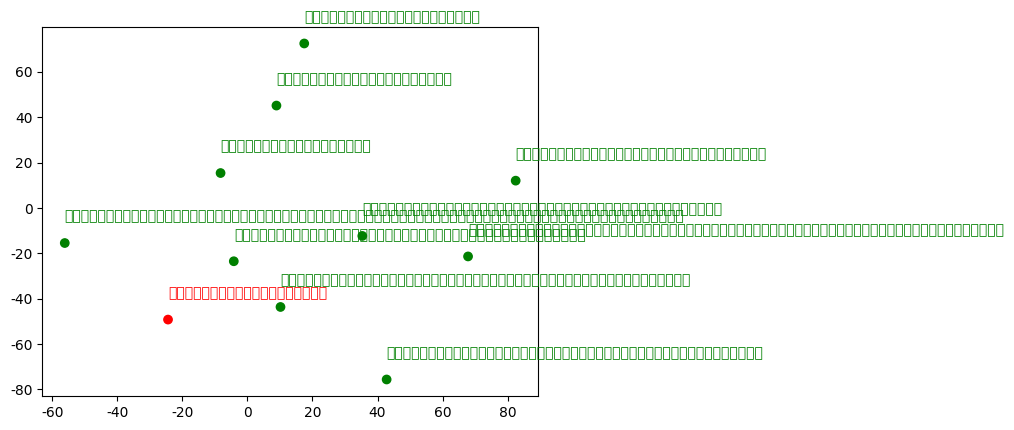

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 设置字体以支持中文显示
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 将查询句子的嵌入添加到句子嵌入数组的首位
all_embeddings = np.vstack([embedded_query, sentence_embeddings])

# 运行 TSNE 降维，固定随机种子以保持结果一致
# n_components (整数): 这个参数指定目标空间的维度。在这里设置为 2，意味着t-SNE将把数据降维到二维空间。
# perplexity (浮点数): 这个参数是t-SNE中非常重要的一个参数，可以看作是考虑周围邻居的数量，它反映了数据局部结构的复杂性。
tsne = TSNE(n_components=2, perplexity=5)  
embeddings_2d = tsne.fit_transform(all_embeddings)

# 创建颜色列表，查询句子为红色，其余为绿色
color_list = ['red'] + ['green'] * len(sentence_embeddings)

# 绘制散点图
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color=color_list)

# 添加文本标签，包括查询句子
sentences_with_query = [query] + sentences  # 加入查询句子到句子列表首位
for i in range(len(embeddings_2d)):
    plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1] + 10,  # 小幅调整文本位置以防重叠
             sentences_with_query[i],
             color=color_list[i])

    
# 显示图表
plt.show()

&emsp;&emsp;从这个结果看，相较于`OpenAI`的`Embedding Models`生成的向量表示，还是有一些差距，至少从上述可视化图表中发现相似的文本并没有很好的分布在相邻的簇中。但其实这并不绝对，因为`TSNE`降维本身就是一个不稳定的过程，可能在原始的高维向量表示中并不会出现这样的问题。所以大家仅把上述可视化结果作为一个直观参考即可，在开源的`Embedding` 模型中，`bge-m3`生成的词向量还是比较优秀的。当然，开源模型的性能相较于在线模型，尤其是跟`OpenAI`的模型相比，存在很大的差距这也是实际存在的。

- Embedding模型评测榜单

&emsp;&emsp;那么如何根据自己的数据情况选择最合适的`Embedding` 模型呢，这里有一个基本的衡量方法。首先，在`Huggging Face` 的 `mteb/leaderboard` 有一个较为优质的评测榜单：https://huggingface.co/spaces/mteb/leaderboard ，该榜单中包含了很多`Embedding` 模型，并且每个模型都给出了在不同任务上的得分。

### 5. 计算向量之间的相似度

### 6. 向量数据库详解